## Site Term calculation

This notebook contains all the calculations and functions to structurally find the site term for each station. In order to do so the following steps are being followed:

- #### 1. Data Download : 
    <small>from disk or downloaded all the stations for each event given in a csv file that resembles a normal query from USGS or EMSC. The Instrument response is deconvolved, if read from disk this is already done.</small>

- #### 2. SNR calculation:
    <small> for each station and event the SNR ratio should be calculated of each arrival towards a noise window which is set pre event. Based on the mean SNR of the body wave arrivals, a cutoff distance is set, where 90% of the stations have a higher Lg wave SNR than a threshold (a threshold of 3.5 is advised). Based on this stations who generally have a lower SNR, or have a higher event-station distance will be filtered out. </small>

- #### 3. Seismogram envelope calculation
    <small> now we calculate the envelopes of each seismogram that is left after filtering based on the SNR and the cutoff distance.  This is done with the Hilbert transform: $${ E(t)={\sqrt {({{Re }}(s(t)))^{2}+({{Im }}(s(t)))^{2}}}}$$, where the Real part is the trace itself and the imaginary part its Hilbert transform. Then we take care of sampling rates, we only consider traces with a sampling rate higher than 10Hz. The envelopes are subsequently smoothed over with a moving average box of 50 seconds width.</small>

- #### 4. Setting of coda time window
    <small> since we want to get rid of the Site term, and we assume that for long enough lapse times the record is independent of distance, source and radiation term, we propose a normalisation of each amplitude by the ratio of the amplitudes within a code time window between each station and a reference station. Doing this, we correct each station in relation to one reference station, which leaves us only with the attenuation term and the source term in the amplitude expression. Therefore it is of large importance to choose a coda time window, which is well in the coda, but at the same time has sufficient energy, in order not to be disturbed by direct arrivals or being nothing but noise. We set the coda time window in dependance of the cutoff distance. The cutoff distance defines the radius we consider, so the largest event-station distance. We divide the cutoff distance by a velocity of 3km/s, which is slower than the body waves, Lg waves and about the velocity of a surface wave. Then we multiply this time by a factor (preferably 1.1), to make sure we really do not consider any direct arrivals. Using this theorem we end upp with rather good coda SNR, while being already good in the parallel regime regarding the slopes of the envelopes. This coda time window is in theory directly computed in step 2, where the cutoff distance is calculated. </small>

- #### 5. Testing of coda time window
    <small> In order to find out if the time window is in fact appropriate, several tests can be run. First of all a visual inspection of the envelopes can be done, with the coda time window plotted on it. Fundamentally the envelopes should be parallel to one another, meaning independent of the distance between station and event the amplitude decays similarly. This can be quantified by looking at the slopes of each envelope within the window. Another test can be done, which already comes close to the actual site term calculation. We divide two smoothed envelopes from one another, one could be a potential reference station. If we are well in the scattering regime, the ratio of the two traces should be rather horizontal, towards zero slope. However, the same applies to the noise regime, where the ratio also has no slope. </small>

- #### 6. SNR computation of the coda time window
    <small> Clearly stations that have poor SNR also in the coda, can not be considered, in order not to introduce a bias. So in order to only use meaningful and physical datapoints we force two criteria. One is a SNR higher than 2 for the whole coda time window, the other is a SNR higher than 2 for the last 20 seconds of the coda time window. By doing this we get rid of stations that have generally weak coda SNR, but also of those who enter already in the noise towards the end of the window. </small>

- #### 7. Find a reference station for each event
    <small> Subsequently, a reference station has to be found for each event. We choose a Geoscope station to be the global reference station, since it recorded for a long time and high quality. We choose station SSB, which recorded 82 out of 94 events from the preliminary catalogue, 17 of which recordings fulfill the two criteria. In case an event is not recorded by the main reference station, a list of other fallback stations is checked. For each of the fallback stations as many events as possible are found, where the fallback station and the main reference station have simultaneously recorded and have a coda SNR higher than 2. Then the ratio between the amplitudes of the coda within the window at both station is computed, of which the median is taken. If in fact an event is not or not sufficiently enough recorded by the main reference station, the median ratio of the fallback station and the main reference station is used to approach the reference station: $$med(\frac{A_{reference}}{A_{fallback}}) \cdot A_{fallback}(event)$$. </small>

- #### 8. Calculation of the Site Term
    <small> When all the possible amplitude ratios are calculated, the final site term for each station can be found. This is done by defining the median of all available measurements as the site term, the advantage being here that we have an idea about the standard deviation.</small>

- #### 9. Following all the previous steps for several frequency bands
    <small> Since the site term is frequency dependent, we need to go through all the steps above individually for all needed frequency bands. </small>


<br/><br/><br/><br/><br/><br/>

Sehr geehrte Damen und Herren,

auf der Suche nach einer Moeglichkeit nach meinem Masterstudium in einem spannenden Forschungsbereich sowie politisch und gesellschaftlich wichtigen Bereich zu arbeiten, habe ich Ihr Angebot entdeckt. 
Mein Name ist Leon Schreiner, und ich bin aktuell Master Student an der Universite Grenoble Alpes im Studiengang Geophysics and Earth Imaging. Im moment schliesse ich das Studium ab, und befinde mich in der Master Thesis. Meine aktuelle Arbeit ist im Bereich der Seismologie, meine Kolleg*innen und ich beschaeftigen uns mit der Erforschung und Kartierung der Ausbreitung der Lg Welle, welche eine spezifische Welle ist, die sich nach Erdbeben in der kontinentalen Erdkruste ausbreitet. Mein Bachelor habe ich am Karlsruher Institut fuer Technologie absolviert, ebenfalls in Geophysik mit Schwerpunktfach Ingenieurs- und Hydrogeologie.

Ich bin sehr begeistert von dem von Ihnen angebotenen Traineeship, ich denke es bietet viele Moeglichkeiten sowohl in wissenschaftlich exzellenten Einrichtungen, wie dem BGR, zu arbeiten, als auch Feldarbeit und die Anwendung der Forschung im Sinne von Aufbereitung der interpretierten Datensaetze vor Ort in Amman zu absolvieren. Ich bin es gewohnt mit grossen und teils sehr grossen Datenstrukturen und Saetzen zu arbeiten, und mithilfe computergestuetzter Auswertung Interpretationsansaetze zu erarbeiten. Allerdings ist eine direkte Zusammenarbeit mit einer Organisation wie der WAJLabs und generell dem WEF Nexus in Jordanien fuer mich etwas neues, wie auch eine grosse Motivation. Etwas so essentielles wie eine sichere und dauerhafte Wasserversorgung zu gewaehrleisten, oder mit Forschung und Datenauswertung zumindest zu unterstuetzen ist fuer mich sehr motivierend und der Kern angewandter Forschung. 

Ganz persoenlich sehe ich das Traineeship als Chance, das Wissen, die Vorgehensweisen und vor allen Dingen den wissenschaftlichen Umgang mit Problemen und Daten, das ich mir waehrend des Studiums angeeignet habe in einem Projekt mit spannendem und wichtigem Bezug anzuwenden, und mein fachliches Wissen sowie andere Skills zu erweitern. Ich habe wie bereits erwaehnt Erfahrung im wissenschaftlichen Umfeld, habe kuerzere (jeweils um die 2 Monate) Praktikumsaufenthalte am AWI und GFZ absolviert, und meine Bachelorthesis am Geophysikalischen Institut des KIT geschrieben. Fuer meine Masterarbeit bin ich aktuell am ISTerre in Grenoble. Ich habe sehr gute Programmierkentnisse, bin dazu imstande physikalische Konzepte mit grossen Datenmengen zu hinterfragen und zu erarbeiten, und selbststaendig Daten mit Sicht auf Interpretation darzustellen.

Darueber hinaus habe ich durch mehrere laengere Aufenthalten in Indien sowie dem suedasiatischen Raum interkulturelle Kompetenz, und bin es gewohnt mich neue Begebenheiten anzupassen. Ich spreche fliessend Englisch, und kann mich gut auf Franzoesisch verstaendigen, nach 19 Monaten Leben in Frankreich.

Ich bin mir im klaren dass ich nicht der perfekte Kandidat fuer das Projekt bin, da sich meine Erfahrungen hauptsaechlich in der Seismologie sowie theoretischen Geophysik befinden, und ich bis Ende Juli noch am ISTerre gebunden bin. Jedoch habe ich durch meine Wahl der Ingenieurs- und Hydrogeologie im Bachelor sowie einer einwoechigen Exkursion grundlegende Kenntnisse, und bin sehr sicher in Signalverarbeitung sowie Datenverarbeitung generell. 

Ich haette einige Fragen zum Projekt selbst, ueber die Methodik, die interdisziplinaere Ausrichtung sowie zu innovativen Moeglichkeiten des Grundwasser Monitorings. Ich wuerde mich sehr ueber eine Ruckmeldung jeder Art, und moeglicherweise ein Gespraech freuen.

Mit freundlichen Gruessen,
Leon Schreiner




#### 1. Data download

In [46]:
from obspy import UTCDateTime
import obspy
from obspy.clients.fdsn import Client
from obspy.clients.fdsn import RoutingClient
from obspy import Stream
from obspy.geodetics import gps2dist_azimuth
from obspy import signal
from obspy import read
import matplotlib.pyplot as plt
import folium
import numpy as np
import json
import pandas as pd
from obspy.clients.fdsn.header import FDSNNoDataException
from scipy.signal import savgol_filter
import os
import folium
import numpy as np
import branca.colormap as cm

from obspy import Stream
from matplotlib.colors import LogNorm

import pandas as pd

Dtmin_Noise=-25
Dtmax_Noise=-5
Dtmin_Pn=-5.
Dtmax_Pn=10.
Dtmin_Sn=-5.
Dtmax_Sn=10.

vLg_max=3.5
vLg_min=3.1
vLg=0.5*(vLg_max+vLg_min)
vPg_max=6.2
vPg_min=5.2
vPg=0.5*(vPg_max+vPg_min)
print(vPg)
#vPg=6.

tminCoda=300.
tmaxCoda=320.
from new_functions import *
import warnings
warnings.filterwarnings("ignore")

5.7


Earthquake at 2023-06-16T16:38:28.069000Z with magnitude 4.8


Processing stations of BGR: 100%|██████████| 193/193 [02:06<00:00,  1.53it/s]


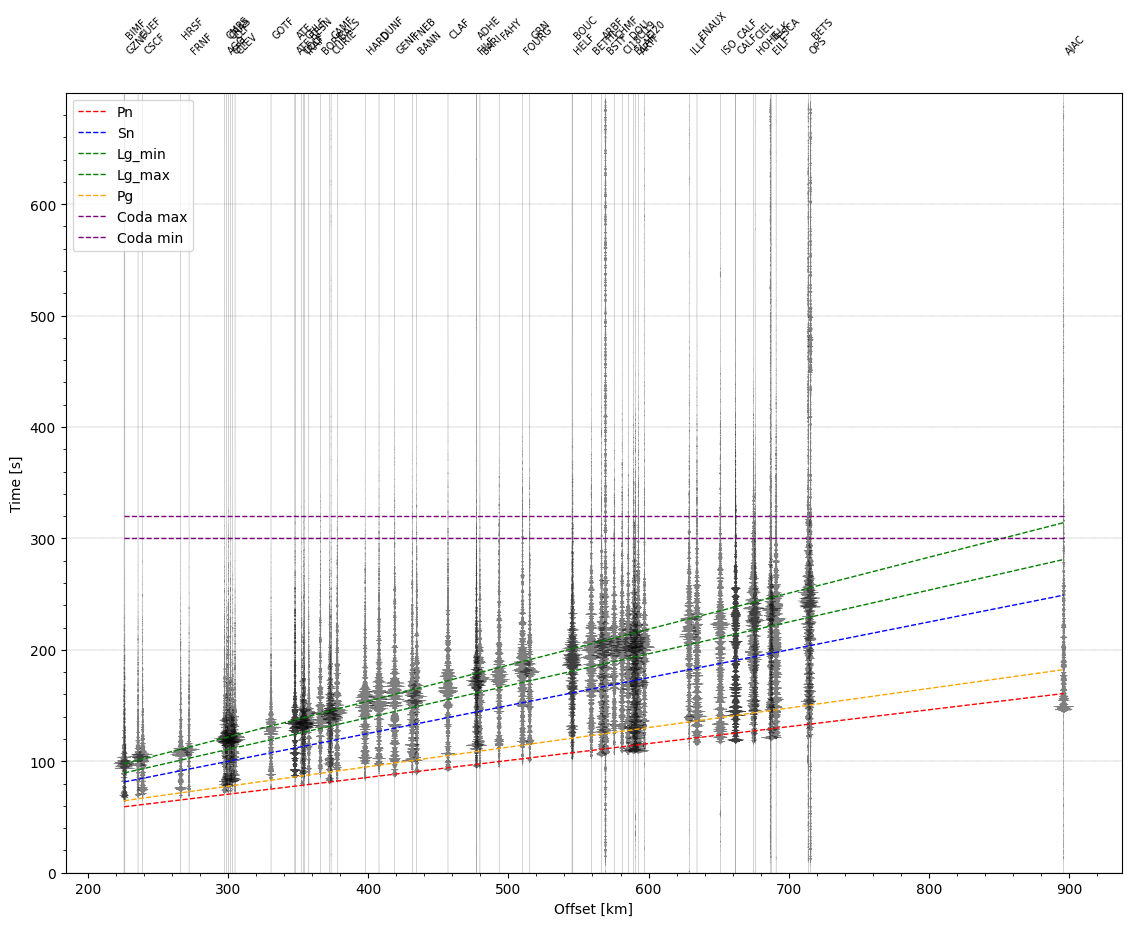

In [53]:
catalogue = pd.read_csv('/home/schreinl/Stage/Data/eq_4_france.csv')
catalogue = catalogue[catalogue['mag'] >= 4.0].reset_index(drop=True)

carte = folium.Map([45, 7], zoom_start=5)

for _, row in catalogue.iterrows():
    infos = f"{row['time']} ({row['latitude']}, {row['longitude']}) {row['mag']} m"
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        tooltip=infos,
        fill=True,
        fill_opacity=1.0,
        radius=4,
    ).add_to(carte)




datacenters =['RESIF','ODC','ETH','INGV','GEOFON', 'IRIS', 'ICGC','BGR']
directory='/home/schreinl/Stage/Data1/'
distmin=1.9
distmax=10.

start = UTCDateTime(catalogue['time'][9]) -25
end = start + 700
eq_lon = float(catalogue['longitude'][9])
eq_lat = float(catalogue['latitude'][9])
st_all, stations_all, plot = big_downloader2(datacenters, start, end, eq_lon, eq_lat, distmin, distmax, directory, plot=False)
time_string = UTCDateTime.strftime(start, format="%Y_%m_%dT%H_%M_%S")



st_plot_filt_all=st_all.copy()
fmin=3
fmax=4
st_plot_filt_all.filter("bandpass", freqmin=fmin, freqmax=fmax)


plot, st_Lg0 = plot_record_section(st_plot_filt_all[0:60], stations_all[0:60], eq_lat, 
eq_lon, start, tracehodo=True, v_Lg_min=vLg_min, v_Lg_max=vLg_max, 
v_Pg=vPg)



carte

#### 4. SNR calculation

In [54]:
snr_threshold = 3.5
eq_start = start

filtered_stations_with_SNR, stations_with_SNR, distance_dict, tcoda_test, filtered_st, stations_with_amps, amp_plot = SNR_all(stations_all, st_plot_filt_all, Dtmin_Pn, Dtmax_Pn, Dtmin_Sn, Dtmax_Sn, vLg_min,vLg_max,vPg_min, vPg_max, tminCoda, tmaxCoda,
         Dtmin_Noise, Dtmax_Noise,eq_start,eq_lat,eq_lon,snr_threshold=snr_threshold,plot_SNR=False,plot_amps=True, wavecode="Lg_Coda",dB=True,codawindow="cutoff",factor=1.2)


calculating SNR for Pn  phase
calculating SNR for Pg  phase
calculating SNR for Sn  phase
calculating SNR for Lg  phase
Reduced from   628  stations to   547  stations due to insufficient SNR or distance >  1007.797726501624
coda window set from 403.11909060064954-503.11909060064954s based on Lg cutoff distance
plotting Lg_Coda amplitudes


In [55]:
st_envelope = obspy.Stream()
smallest = 7000
for tr in st_plot_filt_all:
    data_envelope = envelope_calculator(tr.data)
    npts = tr.stats.npts
    if npts >= smallest:
        samprate = tr.stats.sampling_rate
        t = np.arange(0, npts / samprate, 1 / samprate)
        tr_envelope = obspy.Trace(data=data_envelope, header=tr.stats)
        st_envelope.append(tr_envelope)

amplitudes_full = calc_amps(stations_all, st_plot_filt_all, Dtmin_Pn, Dtmax_Pn, Dtmin_Sn, Dtmax_Sn, vLg_min,vLg_max,vPg_min,vPg_max, tcoda_test, tcoda_test+100, Dtmin_Noise, Dtmax_Noise, eq_start)
amplitudes_small = calc_amps(stations_all, st_plot_filt_all, Dtmin_Pn, Dtmax_Pn, Dtmin_Sn, Dtmax_Sn, vLg_min,vLg_max,vPg_min,vPg_max, tcoda_test+80, tcoda_test+100, Dtmin_Noise, Dtmax_Noise, eq_start)
SNR_dict = select_ratio_dict("Coda_Noise", amplitudes_full)
SNR_dict_small = select_ratio_dict("Coda_Noise", amplitudes_small)
envelopes_amps, st_smooth = envelopes_routine1(time_string, st_envelope, coda_dist_start=tcoda_test, coda_dist_end=tcoda_test + 100, plotting=False, method='cutoff', snr=SNR_dict, snr_window=SNR_dict_small)
filtered_station_names = set(row[1] for row in filtered_stations_with_SNR)
filtered_smooth_stream = obspy.Stream()
filtered_stream = obspy.Stream()
for trace in st_smooth:
    if trace.stats.station in filtered_station_names:
        filtered_smooth_stream.append(trace)
for trace in st_envelope:
    if trace.stats.station in filtered_station_names:
        filtered_stream.append(trace) 

In [56]:
valid = 0
invalid = 0
for i in range(len(filtered_stream)):
    station = filtered_stream[i].stats.station
    if station in envelopes_amps:
        if envelopes_amps[station]['snr_coda'] > 2 and envelopes_amps[station]['snr_coda_end'] > 2:
            valid += 1
        else:
            invalid += 1
    else:
        invalid += 1
print(valid, "valid stations")
print(invalid, "invalid stations")

208 valid stations
355 invalid stations


In [52]:
amplitudes_dict = create_coda_amplitude_dict(event_file='/home/schreinl/Stage/Data/eq_4_france.csv', codawindow="cutoff",fmin=3,fmax=4, factor=1.1,data_dir='Data1')

Checking file: /home/schreinl/Stage/Data1/2025_01_12T13_51_15/2025_01_12T13_51_15_envelope_amps_cutoff_fac_1.1_3_4Hz_dict.txt
Checking file: /home/schreinl/Stage/Data1/2024_06_04T00_34_07/2024_06_04T00_34_07_envelope_amps_cutoff_fac_1.1_3_4Hz_dict.txt
Checking file: /home/schreinl/Stage/Data1/2024_03_27T21_19_12/2024_03_27T21_19_12_envelope_amps_cutoff_fac_1.1_3_4Hz_dict.txt
Checking file: /home/schreinl/Stage/Data1/2024_02_17T00_23_04/2024_02_17T00_23_04_envelope_amps_cutoff_fac_1.1_3_4Hz_dict.txt
Checking file: /home/schreinl/Stage/Data1/2024_02_09T12_05_57/2024_02_09T12_05_57_envelope_amps_cutoff_fac_1.1_3_4Hz_dict.txt
Checking file: /home/schreinl/Stage/Data1/2023_11_21T05_51_40/2023_11_21T05_51_40_envelope_amps_cutoff_fac_1.1_3_4Hz_dict.txt
Checking file: /home/schreinl/Stage/Data1/2023_10_28T15_28_57/2023_10_28T15_28_57_envelope_amps_cutoff_fac_1.1_3_4Hz_dict.txt
Checking file: /home/schreinl/Stage/Data1/2023_09_18T03_09_49/2023_09_18T03_09_49_envelope_amps_cutoff_fac_1.1_3_4Hz_d

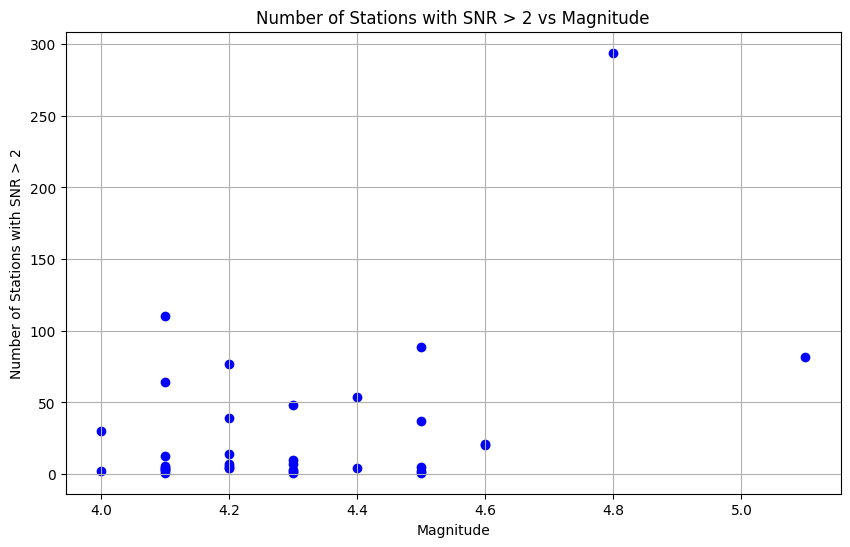

In [44]:
event_station_counts = {}
event_magnitudes = {}

for station, entries in amplitudes_dict.items():
    for entry in entries:
        if entry is not None:
            event_time = entry['time']
            snr_coda = entry.get('snr_coda', 0)
            snr_last_window = entry.get('snr_last_window', 0)
            if snr_coda > 2 and snr_last_window > 2:
                if event_time not in event_station_counts:
                    event_station_counts[event_time] = 0
                    event_magnitudes[event_time] = entry['magnitude']
                event_station_counts[event_time] += 1

# Extract data for plotting
event_times = list(event_station_counts.keys())
station_counts = list(event_station_counts.values())
magnitudes = [event_magnitudes[time] for time in event_times]

# Plotting
plt.figure(figsize=(10, 6))
plt.scatter(magnitudes, station_counts, c='blue', marker='o')
plt.xlabel('Magnitude')
plt.ylabel('Number of Stations with SNR > 2')
plt.title('Number of Stations with SNR > 2 vs Magnitude')
plt.grid(True)
plt.show()

In [42]:
station_counts = {}

for station, entries in amplitudes_dict.items():
    count = 0
    for entry in entries:
        if entry is not None:
            snr_coda = entry.get('snr_coda', 0)
            snr_last_window = entry.get('snr_last_window', 0)
            if snr_coda > 2 and snr_last_window > 2:
                count += 1
    station_counts[station] = count

print(station_counts)

{'GRA': 0, 'ABJF': 11, 'ADHE': 0, 'AGO': 3, 'AJAC': 0, 'ARBF': 1, 'ARTF': 1, 'BALS': 3, 'BANN': 4, 'BARI': 1, 'BETHI': 2, 'BLAF': 1, 'BORF': 5, 'BOUC': 1, 'BOUF': 3, 'BRGF': 9, 'BSCF': 0, 'BSTF': 0, 'CALF': 2, 'CARF': 5, 'CFF': 0, 'CHAMO': 0, 'CHIF': 1, 'CHLF': 3, 'CHMF': 2, 'CIEL': 2, 'CLAF': 1, 'CLF': 3, 'CLMF': 0, 'CMPS': 3, 'COLF': 4, 'COURM': 0, 'CRAS': 2, 'CRNF': 4, 'CSCF': 1, 'CURIE': 0, 'CZNF': 0, 'DAUF': 5, 'DOU': 4, 'DUNF': 7, 'EILF': 0, 'ENAUX': 2, 'ESCA': 1, 'FAHY': 2, 'FILF': 6, 'FNEB': 5, 'FOURG': 3, 'FRNF': 6, 'GARF': 7, 'GENF': 3, 'GIZF': 0, 'GNEF': 4, 'GOTF': 1, 'GRN': 1, 'GZNF': 3, 'HARD': 2, 'HELF': 1, 'HOHE': 1, 'HOUCH': 0, 'HRSF': 12, 'ILLF': 0, 'ISO': 0, 'LABF': 9, 'LAJAS': 2, 'LATF': 2, 'LBL': 5, 'LEMB': 2, 'LEUC': 8, 'LGIF': 10, 'LOUF': 7, 'LRVF': 0, 'MANO': 1, 'MCECU': 0, 'MELF': 3, 'MERIC': 1, 'MFC': 0, 'MIGAL': 1, 'MLS': 9, 'MLYF': 0, 'MLZA': 1, 'MOLES': 2, 'MON': 0, 'MONQ': 9, 'MORSI': 1, 'MTNF': 15, 'MVIF': 0, 'NEEW': 0, 'NEUF': 1, 'NIMR': 0, 'OG02': 1, 'OG

Mean Ratio (GRA / SSB): 0.94441
Standard Deviation: 0.56815
Median: 0.71897
Min Ratio: 0.25246
Max Ratio: 3.00491


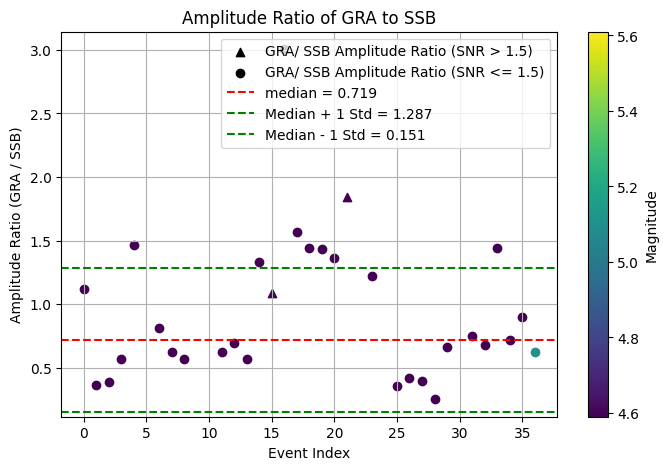

In [41]:
station1 = "GRA"
station2 = "SSB"

denom_amplitudes = np.array([entry['amplitude'] if entry is not None else None for entry in amplitudes_dict[station1]], dtype=np.float64)
counter_amplitudes = np.array([entry['amplitude'] if entry is not None else None for entry in amplitudes_dict[station2]], dtype=np.float64)

denom_amplitudes = np.where(denom_amplitudes == None, np.nan, denom_amplitudes)
counter_amplitudes = np.where(counter_amplitudes == None, np.nan, counter_amplitudes)

ratio = np.divide(denom_amplitudes, counter_amplitudes, out=np.full_like(denom_amplitudes, np.nan), where=(counter_amplitudes != 0))
valid_ratios = ratio[~np.isnan(ratio)]
mean_ratio = np.nanmean(valid_ratios)
std_ratio = np.nanstd(valid_ratios)
median_ratio = np.nanmedian(valid_ratios)
min_ratio = np.nanmin(valid_ratios)
max_ratio = np.nanmax(valid_ratios)

magnitudes = np.array([entry['magnitude'] if entry is not None else None for entry in amplitudes_dict[station1]], dtype=np.float64)
magnitudes = np.where(magnitudes == None, np.nan, magnitudes)

print(f"Mean Ratio ({station1} / {station2}): {mean_ratio:.5f}")
print(f"Standard Deviation: {std_ratio:.5f}")
print(f"Median: {median_ratio:.5f}")
print(f"Min Ratio: {min_ratio:.5f}")
print(f"Max Ratio: {max_ratio:.5f}")

plt.figure(figsize=(8, 5))
plt.scatter([], [], c='k', marker="^", label=f"{station1}/ {station2} Amplitude Ratio (SNR > 1.5)")
plt.scatter([], [], c='k', marker="o", label=f"{station1}/ {station2} Amplitude Ratio (SNR <= 1.5)")

for i, (r, mag) in enumerate(zip(ratio, magnitudes)):
    if not np.isnan(r):
        snr_coda = amplitudes_dict[station1][i].get('snr_coda', None)
        if snr_coda is not None and snr_coda > 1.5:
            plt.scatter(i, r, c=mag, cmap='viridis', marker="^")
        else:
            plt.scatter(i, r, c=mag, cmap='viridis', marker="o")

plt.colorbar(label='Magnitude')
plt.axhline(median_ratio, color="r", linestyle="--", label=f"median = {median_ratio:.3f}")
plt.axhline(median_ratio + std_ratio, color="g", linestyle="--", label=f"Median + 1 Std = {median_ratio + std_ratio:.3f}")
plt.axhline(median_ratio - std_ratio, color="g", linestyle="--", label=f"Median - 1 Std = {median_ratio - std_ratio:.3f}")

plt.xlabel("Event Index")
plt.ylabel(f"Amplitude Ratio ({station1} / {station2})")
plt.title(f"Amplitude Ratio of {station1} to {station2}")
plt.legend()
plt.grid(True)
plt.show()


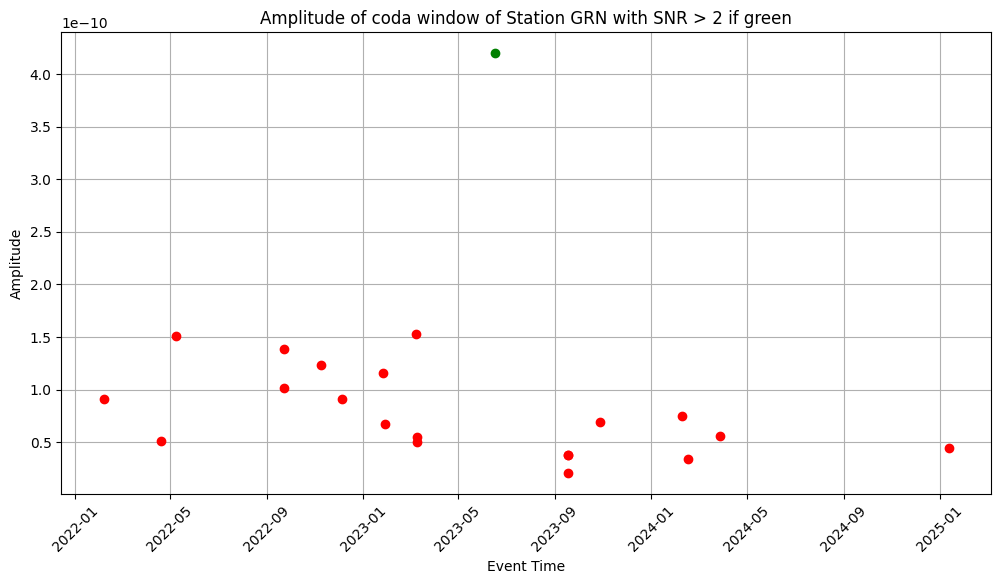

In [ ]:
stationcheck = "GRN"
from datetime import datetime
ech_amplitudes = [entry['amplitude'] if entry is not None else np.nan for entry in amplitudes_dict[stationcheck]]
snr_coda_values = [entry['snr_coda'] if entry is not None else np.nan for entry in amplitudes_dict[stationcheck]]
event_times = [entry['time'] if entry is not None else 'None' for entry in amplitudes_dict['ECH']]
valid_indices = [i for i, time in enumerate(event_times) if time != 'None']
valid_times = [event_times[i] for i in valid_indices]
valid_amplitudes = [ech_amplitudes[i] for i in valid_indices]
valid_snr_coda = [snr_coda_values[i] for i in valid_indices]
valid_times = [datetime.strptime(time, '%Y_%m_%dT%H_%M_%S') for time in valid_times]

plt.figure(figsize=(12, 6))
for time, amplitude, snr_coda in zip(valid_times, valid_amplitudes, valid_snr_coda):
    if snr_coda is not None:
        color = 'green' if snr_coda > 2 else 'red'
        plt.plot(time, amplitude, 'o', color=color)
#plt.text(0.5, 0.5, 'Green: SNR > 2', color='green')
#plt.text(0.5, 0.5, 'Red: SNR <= 2', color='red')
plt.xlabel('Event Time')
plt.ylabel('Amplitude')
plt.title(f'Amplitude of coda window of Station {stationcheck} with SNR > 2 if green')
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

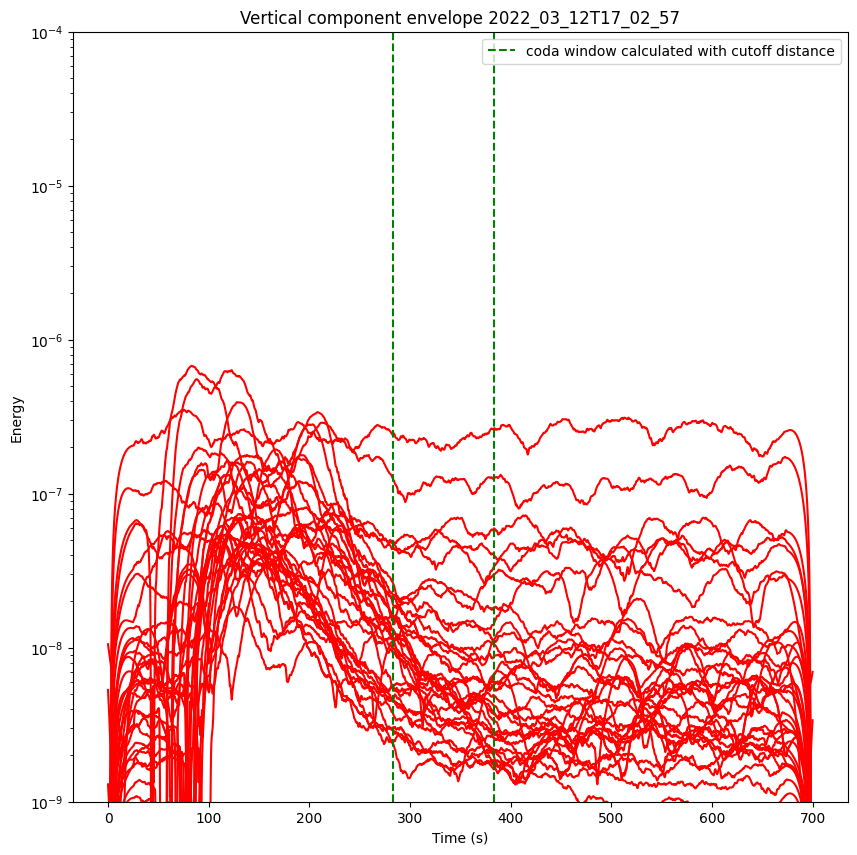

In [34]:
plot_filtered_smoothed = smooth_plot_envelope(time_string, 50,filtered_stream, st_plot_filt_all,method="cutoff distance",
                    tmincoda_dist=tcoda_test, tmaxcoda_dist=tcoda_test+100, savefig=False)